`conda activate r_env_standr`

In [ ]:
suppressPackageStartupMessages({
    library(tibble)
    library(stringr)
    library(tidyverse)
    library(RColorBrewer) 
    library(ggplot2)
    library(dplyr)
    library(Seurat)
    options(stringsAsFactors = FALSE)
    set.seed(123)
})

Warning message:
“package ‘ggplot2’ was built under R version 4.3.3”


### Braun2023 predictions

#### Detailed annotations (Mossi et al.)

In [ ]:
braun2023 <- readRDS('/projects/0/einf2548/cruiz/dmg/data/predictions/malignant_rna_predictions_Braun2023.rds')
braun2023

An object of class Seurat 
19261 features across 258867 samples within 2 assays 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: prediction.score.braun2023.celltype
 2 dimensional reductions calculated: pca, umap

In [ ]:
nmf_assignment <- readRDS('/projects/0/einf2548/cruiz/dmg/notebooks/nmf/data/nmf_assigment_malignant_no_core_programs.rds')
nmf_assignment

,MP_Assignment
,<chr>
BT042_PD_CCGTTCATCTATGTGG-1,unresolved
BT042_PD_CTACCTGGTATGAAAC-1,MP_2_1
BT042_PD_TTGCATTTCCTGTAGA-1,MP_2_1
BT042_PD_GTGCTGGGTAACGCGA-1,MP_2_1
BT042_PD_CTTCTAAAGACGCATG-1,MP_2_1
BT042_PD_CCTCACACAAAGCTAA-1,MP_5_1
BT042_PD_ACAAGCTGTGGCTAGA-1,MP_5_1
BT042_PD_TTCCGGTAGGGAGTTC-1,MP_2_1
BT042_PD_ACAGAAAGTCTATGAC-1,MP_5_1


In [ ]:
braun2023 <- AddMetaData(braun2023, metadata = nmf_assignment)

In [ ]:
braun2023$NMF <- braun2023$MP_Assignment

In [ ]:
braun2023$NMF <- sub("_1$", "", braun2023$NMF)
braun2023$NMF <- factor(braun2023$NMF, 
                      levels = c( "MP_2", "MP_3", "MP_4", "MP_5", 
                                  "MP_7", "MP_8", "MP_9", 
                                 "MP_11", "MP_12", "MP_13", "unresolved"))

In [ ]:
unique(braun2023$predicted.braun2023.celltype)

[1] "Pre-OPC"       "Neuron"        "Radial glia"   "Pre-astrocyte"
 [5] "Neural crest"  "OPC"           "Fibroblast"    "COP"          
 [9] "Vascular"      "Erythrocyte"   "Neuronal IPC"  "Neuroblast"   
[13] "Glioblast"

In [ ]:
braun2023$NMF <- factor(braun2023$NMF,
                       levels=c('MP_4','MP_13','MP_11','MP_12','MP_2',
                                'MP_5','MP_8',
                                'MP_3','MP_7', 'MP_9', 
                                'unresolved'))

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


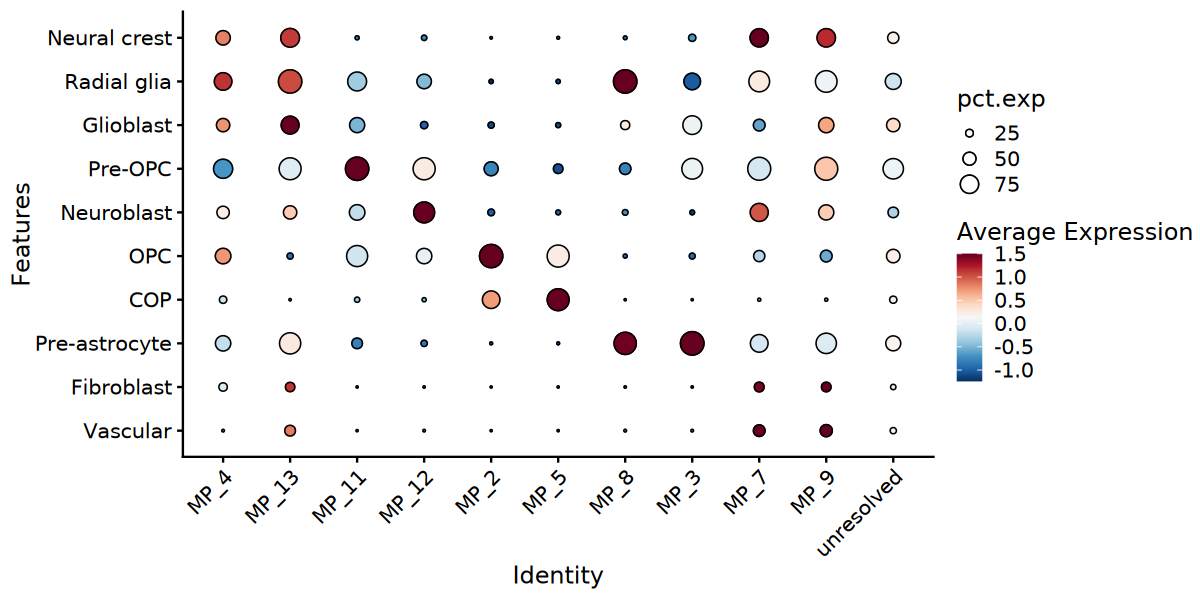

In [ ]:
options(repr.plot.height = 5, repr.plot.width = 10)
DotPlot(braun2023, features = rev(c('Neural crest','Radial glia','Glioblast',
                                    'Pre-OPC','Neuroblast',
                                    'OPC','COP',
                                    'Pre-astrocyte',
                                    'Fibroblast','Vascular')), 
        group.by = 'NMF', assay = 'prediction.score.braun2023.celltype',
       col.min = -1.5, col.max= 1.5) +
  geom_point(aes(size=pct.exp), shape = 21, colour="black", stroke=0.5) +
  scale_color_gradientn(colors = rev(brewer.pal(11, "RdBu"))) + 
  guides(size=guide_legend(override.aes=list(shape=21, colour="black", fill="white")))+coord_flip()+
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) 

In [ ]:
ggsave('braun2023_predicitons_dotplot_ordered.pdf', height = 3.5, width = 7)

### Wang2024 predictions

In [ ]:
wang2024 <- readRDS('/projects/0/einf2548/cruiz/dmg/data/predictions/malignant_rna_predictions_Wang2024.rds')
wang2024

An object of class Seurat 
19313 features across 258867 samples within 3 assays 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 2 other assays present: prediction.score.wang2024.celltype, prediction.score.wang2024_subset.celltype
 2 dimensional reductions calculated: pca, umap

In [ ]:
wang2024 <- AddMetaData(wang2024, metadata = nmf_assignment)

In [ ]:
wang2024$NMF <- wang2024$MP_Assignment

In [ ]:
wang2024$NMF <- sub("_1$", "", wang2024$NMF)
wang2024$NMF <- factor(wang2024$NMF, 
                      levels = c( "MP_2", "MP_3", "MP_4", "MP_5", 
                                  "MP_7", "MP_8", "MP_9", 
                                 "MP_11", "MP_12", "MP_13", "unresolved"))

In [ ]:
unique(wang2024$predicted.wang2024_subset.celltype)

[1] "IPC-Glia"                 "IN-dLGE-Immature"        
 [3] "EN-Newborn"               "Astrocyte-Fibrous"       
 [5] "OPC"                      "Oligodendrocyte-Immature"
 [7] "Astrocyte-Immature"       "EN-Non-IT-Immature"      
 [9] "Oligodendrocyte"          "RG-vRG"

In [ ]:
wang2024$NMF <- factor(wang2024$NMF,
                       levels=c('MP_4','MP_13','MP_11','MP_12','MP_2',
                                'MP_5','MP_8',
                                'MP_3','MP_7', 'MP_9', 
                                'unresolved'))

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


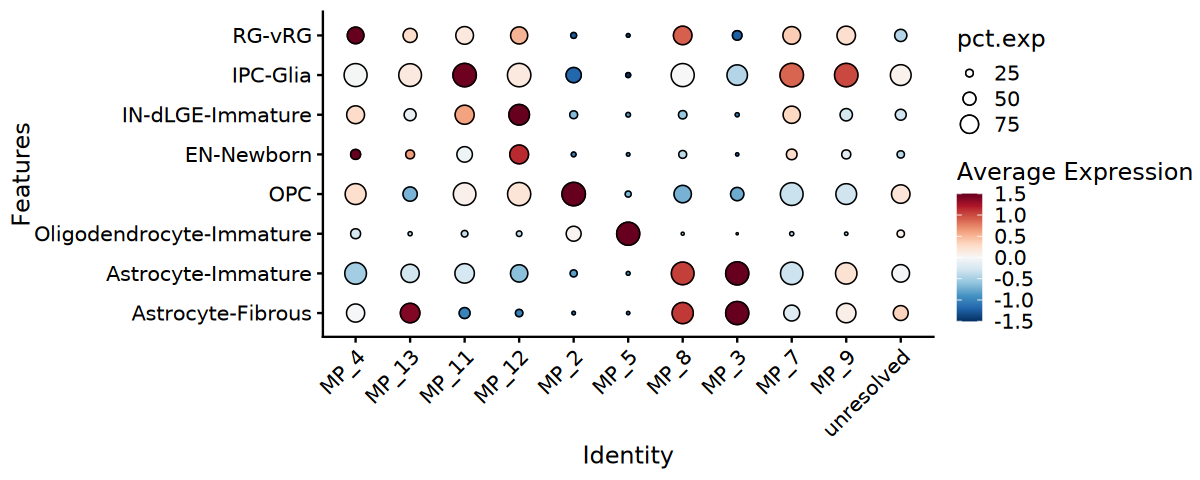

In [ ]:
options(repr.plot.height = 4, repr.plot.width = 10)
DotPlot(wang2024, features = rev(c('RG-vRG','IPC-Glia',
                                   'IN-dLGE-Immature','EN-Newborn',
                                   'OPC','Oligodendrocyte-Immature',
                                   'Astrocyte-Immature','Astrocyte-Fibrous'
                                   )), 
        group.by = 'NMF', assay = 'prediction.score.wang2024_subset.celltype',
       col.min = -1.5, col.max= 1.5) +
  geom_point(aes(size=pct.exp), shape = 21, colour="black", stroke=0.5) +
  scale_color_gradientn(colors = rev(brewer.pal(11, "RdBu"))) + 
  guides(size=guide_legend(override.aes=list(shape=21, colour="black", fill="white")))+coord_flip()+
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) 

In [ ]:
ggsave('wang2024_predicitons_dotplot_ordered.pdf', height = 3, width = 8)

### Li2023 predictions

In [ ]:
li2023 <- readRDS('/projects/0/einf2548/cruiz/dmg/data/predictions/malignant_rna_predictions_Li2023.rds')
li2023

An object of class Seurat 
19290 features across 258867 samples within 2 assays 
Active assay: RNA (19248 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: prediction.score.li2023.celltype
 2 dimensional reductions calculated: pca, umap

In [ ]:
li2023 <- AddMetaData(li2023, metadata = nmf_assignment)

In [ ]:
li2023$NMF <- li2023$MP_Assignment

In [ ]:
li2023$NMF <- sub("_1$", "", li2023$NMF)
li2023$NMF <- factor(li2023$NMF, 
                      levels = c( "MP_2", "MP_3", "MP_4", "MP_5", 
                                  "MP_7", "MP_8", "MP_9", 
                                 "MP_11", "MP_12", "MP_13", "unresolved"))

In [ ]:
unique(li2023$predicted.li2023.celltype)

[1] "Pre-OPC"            "RG"                 "Early OPC-1"       
 [4] "APC2"               "APC1"               "Committed OPC"     
 [7] "Oligodentrocyte"    "Neuron precursor 1" "Early OPC-2"       
[10] "RGlikePC3"          "Early OPC-3"

In [ ]:
li2023$NMF <- factor(li2023$NMF,
                      levels=c('MP_4','MP_13','MP_11','MP_12','MP_2',
                                'MP_5','MP_8',
                                'MP_3','MP_7', 'MP_9', 
                                'unresolved'))

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


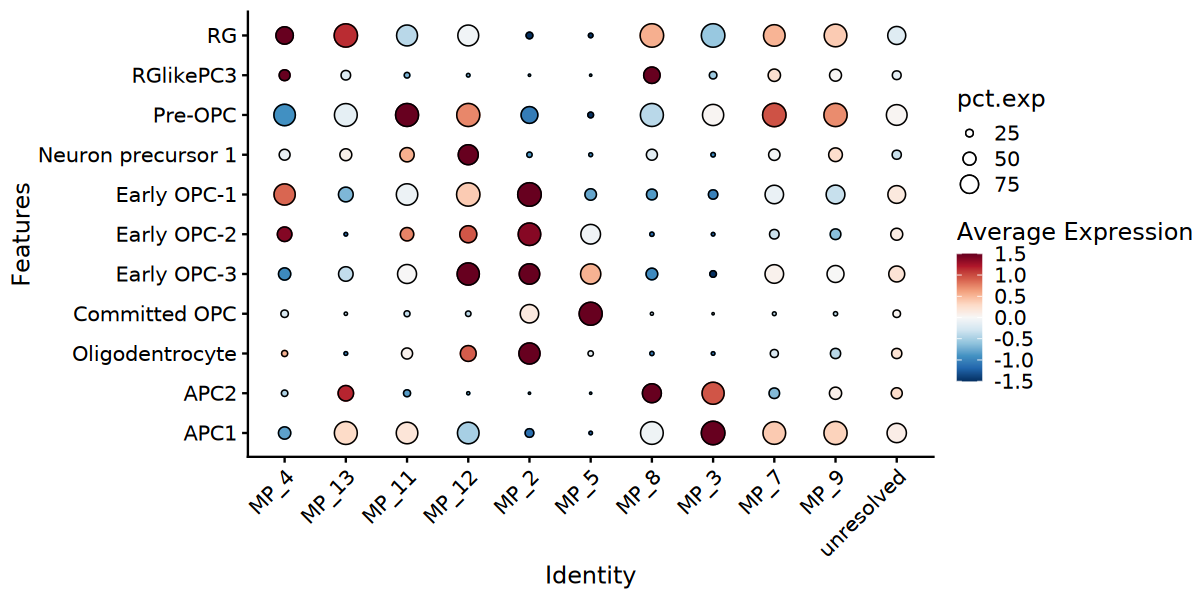

In [ ]:
options(repr.plot.height = 5, repr.plot.width = 10)
DotPlot(li2023, features = rev(c('RG','RGlikePC3',
                                 'Pre-OPC',
                                 'Neuron precursor 1',
                                 'Early OPC-1','Early OPC-2',
                                 'Early OPC-3',
                                 'Committed OPC','Oligodentrocyte','APC2','APC1'
                                              )), 
        group.by = 'NMF', assay = 'prediction.score.li2023.celltype',
       col.min = -1.5, col.max= 1.5) +
  geom_point(aes(size=pct.exp), shape = 21, colour="black", stroke=0.5) +
    scale_color_gradientn(colors = rev(brewer.pal(11, "RdBu"))) + 
  guides(size=guide_legend(override.aes=list(shape=21, colour="black", fill="white")))+coord_flip()+
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) 

In [ ]:
ggsave('li2023_predicitons_dotplot_ordered.pdf', height = 3.8, width = 7.4)